# Recompute Occupation-Level Exposure Scores

This notebook rebuilds two occupation-level scores from task-level data and writes them back into `occ_level_new.csv`.

## Scores

| Score | Formula | Description |
|-------|---------|-------------|
| `dv_rating_new` | $\displaystyle \bar\beta_o = \frac{1}{n_o}\sum_{t \in T_o} \beta^{\text{new}}_t$ | Simple (equal-weight) average of `beta_new` across all tasks in the occupation. |
| `time_based_score` | $\displaystyle \hat\beta_o = \frac{\sum_{t \in T_o} \beta^{\text{new}}_t \cdot \pi_t}{\sum_{t \in T_o} \pi_t}$ | Time-weighted average of `beta_new` using the labour-share weights $\pi_t$ from the O\*NET time-share file. |

## Missing-pi rule

Some tasks in `full_labelset_new.tsv` have no matching row in `New_pi.csv`, so their $\pi_t$ is unknown. For `time_based_score` we apply the following rule:

- If an occupation has **5 or fewer** tasks with missing $\pi$, we compute the weighted average over the tasks that *do* have a valid $\pi$ (i.e. we ignore the missing ones).
- If an occupation has **more than 5** missing $\pi$ values, we treat the coverage as too incomplete and set `time_based_score = NaN`.

`dv_rating_new` is unaffected by missing $\pi$ because it uses no weights.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

BASE = Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1")

TASK_FILE = BASE / "Eloundou_New" / "full_labelset_new.tsv"
OCC_FILE  = BASE / "Eloundou_New" / "occ_level_new.csv"
PI_FILE   = BASE / "Time" / "New_pi.csv"

df_tasks = pd.read_csv(TASK_FILE, sep="\t", low_memory=False)
df_occ   = pd.read_csv(OCC_FILE, skipinitialspace=True)
df_occ.columns = df_occ.columns.str.strip()
df_pi    = pd.read_csv(PI_FILE)

print(f"Tasks       : {len(df_tasks):,} rows")
print(f"Occupations : {len(df_occ):,} rows")
print(f"Pi (time)   : {len(df_pi):,} rows")

Tasks       : 19,265 rows
Occupations : 923 rows
Pi (time)   : 17,325 rows


In [2]:
# ── Normalise keys ────────────────────────────────────────────────────
OCC_COL  = "O*NET-SOC Code"
TASK_COL = "Task ID"

df_tasks[TASK_COL] = pd.to_numeric(df_tasks[TASK_COL], errors="coerce").astype("Int64").astype(str)
df_tasks[OCC_COL]  = df_tasks[OCC_COL].astype(str).str.strip()

df_pi["task_id"]       = pd.to_numeric(df_pi["task_id"], errors="coerce").astype("Int64").astype(str)
df_pi["onetsoc_code"]  = df_pi["onetsoc_code"].astype(str).str.strip()

df_occ[OCC_COL] = df_occ[OCC_COL].astype(str).str.strip()

# ── 1. dv_rating_new  (equal-weight average of beta_new) ─────────────
dv_new = (
    df_tasks.groupby(OCC_COL)["beta_new"]
    .mean()
    .rename("dv_rating_new")
    .reset_index()
)

print(f"dv_rating_new computed for {len(dv_new):,} occupations")
dv_new.head()

dv_rating_new computed for 923 occupations


,O*NET-SOC Code,dv_rating_new
0,11-1011.00,0.451613
1,11-1011.03,0.805556
2,11-1021.00,0.588235
3,11-1031.00,0.366667
4,11-2011.00,0.683333


In [3]:
# ── 2. time_based_score  (pi-weighted average of beta_new) ───────────
MAX_MISSING = 5

merged = df_tasks[[OCC_COL, TASK_COL, "beta_new"]].merge(
    df_pi[["onetsoc_code", "task_id", "pi"]].rename(
        columns={"onetsoc_code": OCC_COL, "task_id": TASK_COL}
    ),
    on=[OCC_COL, TASK_COL],
    how="left",
)

records = []
n_skipped = 0

for occ_id, grp in merged.groupby(OCC_COL):
    n_missing = int(grp["pi"].isna().sum())

    if n_missing > MAX_MISSING:
        records.append({OCC_COL: occ_id, "time_based_score": np.nan})
        n_skipped += 1
        continue

    valid = grp.dropna(subset=["pi", "beta_new"])
    if valid.empty or valid["pi"].sum() == 0:
        records.append({OCC_COL: occ_id, "time_based_score": np.nan})
        n_skipped += 1
        continue

    score = (valid["beta_new"] * valid["pi"]).sum() / valid["pi"].sum()
    records.append({OCC_COL: occ_id, "time_based_score": score})

df_time = pd.DataFrame(records)
n_scored = len(df_time) - n_skipped

print(f"time_based_score computed for {n_scored:,} occupations")
print(f"Skipped (>{MAX_MISSING} missing pi) : {n_skipped:,} occupations")

time_based_score computed for 819 occupations
Skipped (>5 missing pi) : 104 occupations


In [4]:
# ── 3. Write back into occ_level_new.csv ──────────────────────────────
df_occ = df_occ.drop(columns=["dv_rating_new", "time_based_score"], errors="ignore")

df_occ = (
    df_occ
    .merge(dv_new,  on=OCC_COL, how="left")
    .merge(df_time, on=OCC_COL, how="left")
)

df_occ.to_csv(OCC_FILE, index=False)

print(f"Saved {OCC_FILE}  ({len(df_occ):,} rows)")
print(f"\nSample output:")
df_occ[[OCC_COL, "Title", "dv_rating_new", "time_based_score"]].head(10)

Saved /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Eloundou_New/occ_level_new.csv  (923 rows)

Sample output:


,O*NET-SOC Code,Title,dv_rating_new,time_based_score
0,11-1011.00,Chief Executives ...,0.451613,0.475128
1,11-1011.03,Chief Sustainability Officers ...,0.805556,0.550623
2,11-1021.00,General and Operations Managers ...,0.588235,0.653901
3,11-1031.00,Legislators ...,0.366667,NaN
4,11-2011.00,Advertising and Promotions Managers ...,0.683333,NaN
5,11-2021.00,Marketing Managers ...,0.650000,0.724615
6,11-2022.00,Sales Managers ...,0.617647,0.507958
7,11-2032.00,Public Relations Managers ...,0.750000,NaN
8,11-2033.00,Fundraising Managers ...,0.781250,0.772104
9,11-3012.00,Administrative Services Managers ...,0.583333,NaN


In [5]:
# ── 4. observed_penetration_score  (pi-weighted penetration_beta_new) ─
PENETRATION_FILE = BASE / "Anthropic" / "task_penetration.csv"
df_pen = pd.read_csv(PENETRATION_FILE)
print(f"Penetration file: {len(df_pen):,} tasks")

# Normalise join key (strip whitespace)
df_pen["task"] = df_pen["task"].astype(str).str.strip()
df_tasks["Task"] = df_tasks["Task"].astype(str).str.strip()

# Merge penetration scores onto the task-level file
task_pen = df_tasks[[OCC_COL, TASK_COL, "Task"]].merge(
    df_pen[["task", "penetration_beta_new"]].rename(columns={"task": "Task"}),
    on="Task",
    how="left",
)

# Check for penetration tasks that don't match any task in the labelset
pen_tasks_set   = set(df_pen["task"].unique())
label_tasks_set = set(df_tasks["Task"].unique())
unmatched = pen_tasks_set - label_tasks_set

if unmatched:
    print(f"\nWARNING: {len(unmatched):,} tasks in penetration file have NO match "
          f"in full_labelset_new.tsv")
    for t in sorted(unmatched)[:10]:
        print(f"  • {t[:100]}")
    if len(unmatched) > 10:
        print(f"  … and {len(unmatched) - 10} more")
else:
    print("\nAll penetration tasks matched to full_labelset_new.tsv")

n_pen_matched = task_pen["penetration_beta_new"].notna().sum()
print(f"\nTask rows with penetration score: {n_pen_matched:,} / {len(task_pen):,}")

# Bring in pi via the same merge logic as time_based_score
task_pen = task_pen.merge(
    df_pi[["onetsoc_code", "task_id", "pi"]].rename(
        columns={"onetsoc_code": OCC_COL, "task_id": TASK_COL}
    ),
    on=[OCC_COL, TASK_COL],
    how="left",
)

# Compute pi-weighted penetration score per occupation.
# Gate 1: if the occupation has >MAX_MISSING tasks with missing pi → NaN
#         (same rule as time_based_score, ensures consistency).
# Gate 2: among the remaining tasks, only those with BOTH a valid
#         penetration score AND a valid pi contribute to the weighted average.
pen_records = []
n_pen_skipped_pi = 0

for occ_id, grp in task_pen.groupby(OCC_COL):
    n_missing_pi = int(grp["pi"].isna().sum())
    if n_missing_pi > MAX_MISSING:
        pen_records.append({OCC_COL: occ_id, "observed_penetration_score": np.nan})
        n_pen_skipped_pi += 1
        continue

    valid = grp.dropna(subset=["penetration_beta_new", "pi"])
    if valid.empty or valid["pi"].sum() == 0:
        pen_records.append({OCC_COL: occ_id, "observed_penetration_score": np.nan})
        continue

    score = (valid["penetration_beta_new"] * valid["pi"]).sum() / valid["pi"].sum()
    pen_records.append({OCC_COL: occ_id, "observed_penetration_score": score})

df_pen_scores = pd.DataFrame(pen_records)

n_pen_scored = df_pen_scores["observed_penetration_score"].notna().sum()
n_pen_nan    = df_pen_scores["observed_penetration_score"].isna().sum()
print(f"\nobserved_penetration_score computed for {n_pen_scored:,} occupations")
print(f"Skipped (>{MAX_MISSING} missing pi, same rule as time_based_score): {n_pen_skipped_pi:,}")
print(f"Skipped (no penetration+pi overlap): {n_pen_nan - n_pen_skipped_pi:,}")

# Write into occ_level_new.csv
df_occ = df_occ.drop(columns=["observed_penetration_score"], errors="ignore")
df_occ = df_occ.merge(df_pen_scores, on=OCC_COL, how="left")
df_occ.to_csv(OCC_FILE, index=False)

print(f"\nSaved {OCC_FILE}  ({len(df_occ):,} rows)")
df_occ[[OCC_COL, "Title", "dv_rating_new", "time_based_score",
        "observed_penetration_score"]].head(10)

Penetration file: 18,054 tasks

All penetration tasks matched to full_labelset_new.tsv

Task rows with penetration score: 19,327 / 19,327

observed_penetration_score computed for 819 occupations
Skipped (>5 missing pi, same rule as time_based_score): 104
Skipped (no penetration+pi overlap): 0

Saved /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Eloundou_New/occ_level_new.csv  (923 rows)


,O*NET-SOC Code,Title,dv_rating_new,time_based_score,observed_penetration_score
0,11-1011.00,Chief Executives ...,0.451613,0.475128,0.088454
1,11-1011.03,Chief Sustainability Officers ...,0.805556,0.550623,0.000000
2,11-1021.00,General and Operations Managers ...,0.588235,0.653901,0.074485
3,11-1031.00,Legislators ...,0.366667,NaN,NaN
4,11-2011.00,Advertising and Promotions Managers ...,0.683333,NaN,NaN
5,11-2021.00,Marketing Managers ...,0.650000,0.724615,0.386057
6,11-2022.00,Sales Managers ...,0.617647,0.507958,0.210423
7,11-2032.00,Public Relations Managers ...,0.750000,NaN,NaN
8,11-2033.00,Fundraising Managers ...,0.781250,0.772104,0.318873
9,11-3012.00,Administrative Services Managers ...,0.583333,NaN,NaN


In [6]:
TOP_N = 10
cols = [OCC_COL, "Title", "time_based_score", "observed_penetration_score"]

# ── Top & bottom by time_based_score ──────────────────────────────────
df_tbs = df_occ[cols].dropna(subset=["time_based_score"]).copy()
df_tbs["Title"] = df_tbs["Title"].str.strip()

top_tbs = df_tbs.nlargest(TOP_N, "time_based_score").reset_index(drop=True)
top_tbs.index += 1
bot_tbs = df_tbs.nsmallest(TOP_N, "time_based_score").reset_index(drop=True)
bot_tbs.index += 1

print("=" * 80)
print(f"  TOP {TOP_N} OCCUPATIONS BY time_based_score (most exposed)")
print("=" * 80)
display(top_tbs)

print(f"\n{'=' * 80}")
print(f"  BOTTOM {TOP_N} OCCUPATIONS BY time_based_score (least exposed)")
print("=" * 80)
display(bot_tbs)

# ── Top & bottom by observed_penetration_score ────────────────────────
df_ops = df_occ[cols].dropna(subset=["observed_penetration_score"]).copy()
df_ops["Title"] = df_ops["Title"].str.strip()

top_ops = df_ops.nlargest(TOP_N, "observed_penetration_score").reset_index(drop=True)
top_ops.index += 1
bot_ops = df_ops.nsmallest(TOP_N, "observed_penetration_score").reset_index(drop=True)
bot_ops.index += 1

print(f"\n{'=' * 80}")
print(f"  TOP {TOP_N} OCCUPATIONS BY observed_penetration_score (most observed)")
print("=" * 80)
display(top_ops)

print(f"\n{'=' * 80}")
print(f"  BOTTOM {TOP_N} OCCUPATIONS BY observed_penetration_score (least observed)")
print("=" * 80)
display(bot_ops)

  TOP 10 OCCUPATIONS BY time_based_score (most exposed)


,O*NET-SOC Code,Title,time_based_score,observed_penetration_score
1,13-2082.00,Tax Preparers,1.000000,0.167843
2,15-2021.00,Mathematicians,1.000000,0.387028
3,19-1011.00,Animal Scientists,0.983698,0.000000
4,27-3043.05,"Poets, Lyricists and Creative Writers",0.969414,0.390790
5,15-1243.00,Database Architects,0.960037,0.472042
6,43-9081.00,Proofreaders and Copy Markers,0.957446,0.138358
7,15-1254.00,Web Developers,0.953524,0.519380
8,19-3011.01,Environmental Economists,0.952313,0.163265
9,15-2041.00,Statisticians,0.945637,0.288383
10,13-2099.01,Financial Quantitative Analysts,0.929445,0.479054



  BOTTOM 10 OCCUPATIONS BY time_based_score (least exposed)


,O*NET-SOC Code,Title,time_based_score,observed_penetration_score
1,29-2012.01,Histology Technicians,0.0,0.0
2,29-2053.00,Psychiatric Technicians,0.0,0.0
3,31-1132.00,Orderlies,0.0,0.0
4,35-9011.00,Dining Room and Cafeteria Attendants and Barte...,0.0,0.0
5,35-9021.00,Dishwashers,0.0,0.0
6,45-2041.00,"Graders and Sorters, Agricultural Products",0.0,0.0
7,45-4011.00,Forest and Conservation Workers,0.0,0.0
8,45-4021.00,Fallers,0.0,0.0
9,47-2022.00,Stonemasons,0.0,0.0
10,47-2043.00,Floor Sanders and Finishers,0.0,0.0



  TOP 10 OCCUPATIONS BY observed_penetration_score (most observed)


,O*NET-SOC Code,Title,time_based_score,observed_penetration_score
1,15-1243.01,Data Warehousing Specialists,0.801446,0.706943
2,11-3031.03,Investment Fund Managers,0.689381,0.679878
3,15-1251.00,Computer Programmers,0.897743,0.633090
4,15-2051.01,Business Intelligence Analysts,0.679562,0.615065
5,15-1212.00,Information Security Analysts,0.629900,0.567471
6,13-1161.01,Search Marketing Strategists,0.834161,0.549178
7,15-2099.01,Bioinformatics Technicians,0.928124,0.541954
8,15-1254.00,Web Developers,0.953524,0.519380
9,13-1161.00,Market Research Analysts and Marketing Special...,0.831084,0.512787
10,43-9111.00,Statistical Assistants,0.791392,0.486003



  BOTTOM 10 OCCUPATIONS BY observed_penetration_score (least observed)


,O*NET-SOC Code,Title,time_based_score,observed_penetration_score
1,11-1011.03,Chief Sustainability Officers,0.550623,0.0
2,11-3013.00,Facilities Managers,0.260900,0.0
3,11-3051.02,Geothermal Production Managers,0.278809,0.0
4,11-3051.03,Biofuels Production Managers,0.160477,0.0
5,11-3051.06,Hydroelectric Production Managers,0.417663,0.0
6,11-3071.04,Supply Chain Managers,0.589831,0.0
7,11-3111.00,Compensation and Benefits Managers,0.551315,0.0
8,11-3121.00,Human Resources Managers,0.414264,0.0
9,11-9041.00,Architectural and Engineering Managers,0.522751,0.0
10,11-9041.01,Biofuels/Biodiesel Technology and Product Deve...,0.415871,0.0


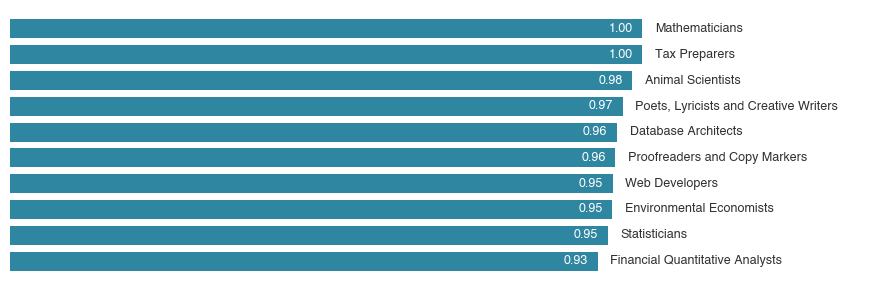

Saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/top10_time_based_score_clean.png


In [18]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
import numpy as np
import pandas as pd

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
})

REPORT_DIR = Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images")
REPORT_DIR.mkdir(exist_ok=True)

# ── Data: top 10 only ────────────────────────────────────────────────
_cols = [OCC_COL, "Title", "time_based_score"]
_df = df_occ[_cols].dropna(subset=["time_based_score"]).copy()
_df["Title"] = _df["Title"].str.strip()

top10 = (
    _df.nlargest(10, "time_based_score")
       .sort_values("time_based_score", ascending=True)
       .reset_index(drop=True)
)

labels = top10["Title"].tolist()
scores = top10["time_based_score"].tolist()
n = len(labels)

# ── Style ────────────────────────────────────────────────────────────
BAR_COLOR = "#2F86A0"
TEXT_COLOR = "#333333"
VALUE_COLOR = "white"

# tighter vertical packing
step = 0.3
y_pos = np.arange(n) * step
bar_height = 0.22

# ── Figure ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 3))
fig.patch.set_alpha(0)
ax.set_facecolor("white")
ax.patch.set_alpha(0.0)

bars = ax.barh(
    y_pos,
    scores,
    height=bar_height,
    color=BAR_COLOR,
    edgecolor="none",
    zorder=3
)

# value labels inside bars
for y, score, label in zip(y_pos, scores, labels):
    ax.text(
        score - 0.015, y, f"{score:.2f}",
        ha="right", va="center",
        fontsize=9, fontweight="bold",
        color=VALUE_COLOR, zorder=4
    )
    ax.text(
        score + 0.02, y, label,
        ha="left", va="center",
        fontsize=9, color=TEXT_COLOR,
        zorder=4
    )

# ── Cleanup ──────────────────────────────────────────────────────────
ax.set_xlim(0, max(scores) * 1.35)
ax.set_ylim(-bar_height, y_pos[-1] + bar_height)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_yticks([])
ax.set_xticks([])
ax.tick_params(left=False, bottom=False)

plt.tight_layout()
out = REPORT_DIR / "top10_time_based_score_clean.png"
plt.savefig(out, dpi=220, bbox_inches="tight", transparent=True)
plt.show()
print(f"Saved: {out}")

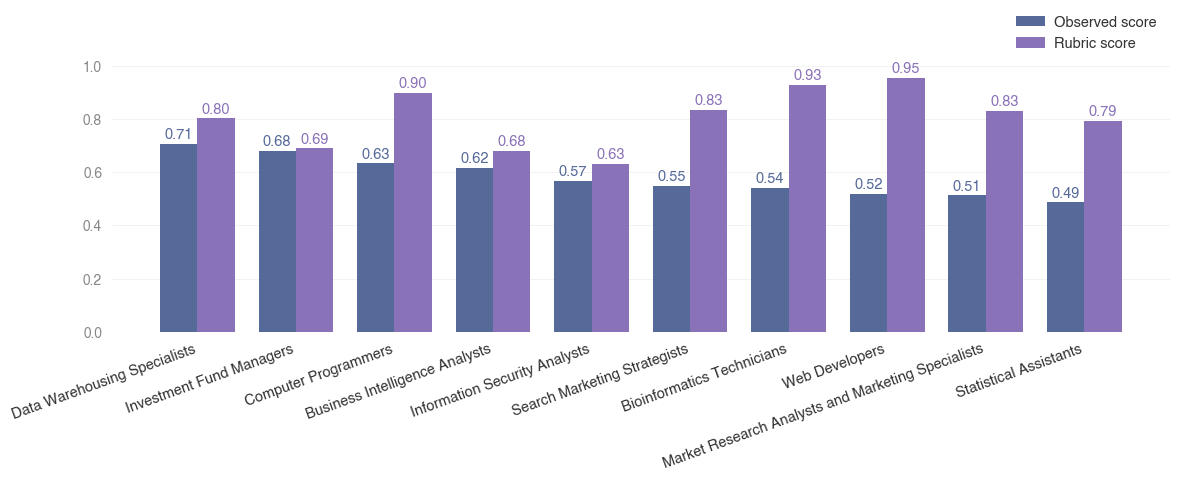

Saved: /Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images/top10_observed_vs_rubric.png


In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

REPORT_DIR = Path("/Users/nicobagnoli/Documents/PYTHON/SMP500-1/Report images")
REPORT_DIR.mkdir(exist_ok=True)

_cols = [OCC_COL, "Title", "time_based_score", "observed_penetration_score"]
_df = df_occ[_cols].dropna(subset=["observed_penetration_score", "time_based_score"]).copy()
_df["Title"] = _df["Title"].str.strip()

top10 = _df.nlargest(10, "observed_penetration_score").reset_index(drop=True)

titles = top10["Title"].tolist()
obs_scores = top10["observed_penation_score"].tolist() if "observed_penation_score" in top10.columns else top10["observed_penetration_score"].tolist()
tbs_scores = top10["time_based_score"].tolist()
n = len(titles)

OBS_COLOR = "#566A9A"
TBS_COLOR = "#8A72B8"   # slightly brighter purple

x = np.arange(n)
bar_w = 0.38

fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_alpha(0)
ax.patch.set_alpha(0.0)

bars_obs = ax.bar(
    x - bar_w / 2, obs_scores, bar_w,
    color=OBS_COLOR, edgecolor="none", zorder=3
)
bars_tbs = ax.bar(
    x + bar_w / 2, tbs_scores, bar_w,
    color=TBS_COLOR, edgecolor="none", zorder=3
)

for bar, val in zip(bars_obs, obs_scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.008,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=10.5,
        fontweight="normal",
        color=OBS_COLOR,
        zorder=5
    )

for bar, val in zip(bars_tbs, tbs_scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        val + 0.008,
        f"{val:.2f}",
        ha="center",
        va="bottom",
        fontsize=10.5,
        fontweight="normal",
        color=TBS_COLOR,
        zorder=5
    )

ax.set_xticks(x)
ax.set_xticklabels(
    titles,
    rotation=20,
    ha="right",
    fontsize=10.5,
    color="#333333"
)

ax.set_ylim(0, max(max(obs_scores), max(tbs_scores)) * 1.18)
ax.tick_params(axis="y", labelsize=10, colors="#888888")
ax.yaxis.grid(True, color="#E8E8E8", linewidth=0.4, zorder=0)
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(left=False, bottom=False)

legend_handles = [
    mpatches.Circle((0, 0), radius=5, facecolor=OBS_COLOR, edgecolor="none",
                    label="Observed score"),
    mpatches.Circle((0, 0), radius=5, facecolor=TBS_COLOR, edgecolor="none",
                    label="Rubric score"),
]

leg = ax.legend(
    handles=legend_handles,
    loc="upper right",
    bbox_to_anchor=(1.0, 1.10),   # more raised
    frameon=False,
    fontsize=10.5,
    labelcolor="#333333",
    handletextpad=0.6,
    handler_map={mpatches.Circle: plt.matplotlib.legend_handler.HandlerPatch()}
)
leg.set_zorder(10)

plt.tight_layout()
out = REPORT_DIR / "top10_observed_vs_rubric.png"
plt.savefig(out, dpi=200, bbox_inches="tight", transparent=True)
plt.show()
print(f"Saved: {out}")